In [1]:
import xarray as xr
import numpy as np
from stompy.plot import nbviz, plot_wkb, plot_utils
from stompy.grid import unstructured_grid
from stompy.spatial import wkb2shp
from stompy import utils, filters, memoize
from stompy.io.local import usgs_nwis 
import shlex
import pandas as pd
import statsmodels.formula.api as smf

import os
import six
import seaborn as sns
import matplotlib.pyplot as plt
import stompy.model.delft.waq_scenario as dwaq
import stompy.model.delft.io as dio

In [2]:
%matplotlib ipympl

In [3]:
cache_dir='cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

In [23]:
six.moves.reload_module(dwaq)
hydros = dict(
    summer=dwaq.HydroFiles(hyd_path="../v148_jun_28_2016_dwaq_merge/com-v148_jun_28_2016_dwaq_merge.hyd"),
    winter=dwaq.HydroFiles(hyd_path="../v148_feb_2016_dwaq_merge/com-v148_feb_2016_dwaq_merge.hyd")
)

In [72]:
# For report, ignore the fast-decaying tracer version.
multi_run_dirs =[
    "./data_lsb_tracer_03", # winter. drop diurnal chl forcing
    "./data_lsb_tracer_02" # summer. additional Palo Alto source, maybe better pond tracer values.    
]

map_ds=xr.open_dataset(os.path.join(multi_run_dirs[0],'dwaq_map.nc')) 

In [24]:
def hydro(run_dir): # had been a value before, not method
    if run_dir in {"./data_lsb_tracer_03","./data_lsb_tracer_04"}: 
        hydro_name='winter'
    else:
        hydro_name='summer'
    return hydros[hydro_name]

In [90]:
# Locations of scalar sources
#inp=dwaq.InpReader(os.path.join(multi_run_dirs[1],'waqmodel.inp'))
#inp.get_transect_by_name('alv2')

In [40]:
# Extract flow manually. Scans the hydro which takes some time.
# Cache results in the waq run directory

def transect_flow(run_dir,transect_name,quantity='Q',force=False, time_range=None):
    cache_dir=os.path.join(run_dir,"cache")
    if not os.path.exists(cache_dir):
        os.makedirs(cache_dir)
    cache_basename = f"{quantity}_{transect_name}.nc"
    cache_fn = os.path.join(cache_dir,cache_basename)
    print(f"Cache is {cache_fn}, force is {force}")
    if time_range is not None:
        force=True
        cache_fn=None
    if force or not os.path.exists(cache_fn):
        hyd = hydro(run_dir)
        inp=dwaq.InpReader(os.path.join(run_dir,'waqmodel.inp'))
        extracted=hyd.extract_transect_flow(inp.get_transect_by_name(transect_name),quantity=quantity,
                                            time_range=time_range)
        if cache_fn is not None:
            extracted.to_netcdf(cache_fn)
    else:
        extracted=xr.load_dataarray(cache_fn)
        
    return extracted

    

In [73]:
g=unstructured_grid.UnstructuredGrid.read_ugrid(map_ds)
shore=g.boundary_polygon()
tri,tri_srcs=g.mpl_triangulation(return_sources=True)

INFO:join_features:0 open strings, 24 simple polygons
INFO:join_features:Building index
INFO:UnstructuredGrid:Warning, boundary_polygon() failed using edges!  Trying polygon union method


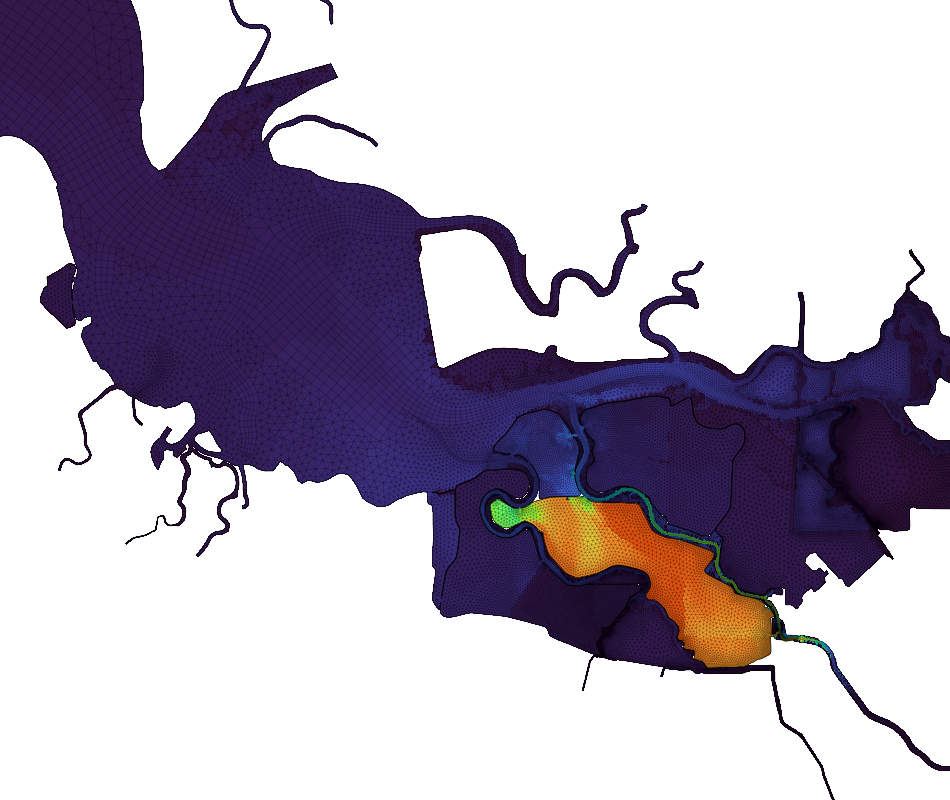

In [75]:
if 1: # scalar planview plot
    fig,ax=plt.subplots(figsize=(9.5,8))

    scal=map_ds.pond_chl.isel(layer=0,time=-1)

    dry=scal==-999

    tri_scalar=scal[tri_srcs]
    ax.tripcolor(tri,facecolors=scal[tri_srcs],cmap='turbo',clim=[0,8])
    g.plot_edges(ax=ax,color='k',alpha=0.3,lw=0.5)
    plot_wkb.plot_wkb(shore,fc='none',ec='k',lw=0.4,zorder=3)

    ax.set_position([0,0,1,1])
    ax.axis('off')
    ax.axis('equal')
    ax.axis( (576015., 593479., 4140885., 4152402.))

In [53]:
if 0: # In-pond distribution of concentration
    zoom=(583787., 593113., 4139756., 4147609.)
    cell_in_zoom=g.cell_clip_mask(zoom)

    for field in ['pond_chl','pond_agec','san_jose']:
        fig,ax=plt.subplots(figsize=(9.5,8))

        scal=map_ds[field].isel(layer=0,time=-1)
        dry=map_ds['LocalDepth'].isel(layer=0,time=-1).values<0.01
        scal=np.where(dry,np.nan,scal)

        cmax=1.2*np.percentile(scal[np.isfinite(scal)&cell_in_zoom],94)

        tri_scalar=scal[tri_srcs]
        coll=ax.tripcolor(tri,facecolors=scal[tri_srcs],cmap='turbo',clim=[0,cmax])

        plot_wkb.plot_wkb(shore,fc='0.8',lw=0.4,zorder=-1)
        plot_wkb.plot_wkb(shore,fc='none',ec='k',lw=0.4,zorder=3)

        ax.set_position([0,0,1,1])
        ax.axis('off')
        ax.axis('equal')
        ax.axis( zoom)
        cax=fig.add_axes([0.05,0.1,0.35,0.03])
        plt.colorbar(coll,cax=cax,label=field,orientation='horizontal')


In [79]:
g_dfm = unstructured_grid.UnstructuredGrid.read_dfm("../dfm_2016_runs/lsb_v148_wcs11bias_dredged_net.nc")

In [88]:
#fig,ax=plt.subplots()
#g_dfm.plot_edges(ax=ax,color='k',lw=0.5,alpha=0.5)
#g_dfm.write_ugrid('dfm_mesh_ugrid.nc')

<xarray.Dataset> Size: 9MB
Dimensions:      (node: 80777, face: 110783, maxnode_per_face: 4, edge: 191582,
                  node_per_edge: 2)
Coordinates:
    node_x       (node) float64 646kB 6.067e+05 5.066e+05 ... 5.897e+05
    node_y       (node) float64 646kB 4.213e+06 4.212e+06 ... 4.144e+06
Dimensions without coordinates: node, face, maxnode_per_face, edge,
                                node_per_edge
Data variables:
    mesh         int64 8B 1
    face_node    (face, maxnode_per_face) int32 2MB 45 46 47 48 ... 46 57 60 47
    edge_node    (edge, node_per_edge) int32 2MB 46 47 47 ... 80471 47994 48421
    face_x       (face) float64 886kB 4.919e+05 6.094e+05 ... 4.934e+05
    face_y       (face) float64 886kB 4.199e+06 4.209e+06 ... 4.197e+06
    mark         (face) int32 443kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    _edge_mark   (edge) int32 766kB -99 -99 -99 -99 -99 ... -99 -99 -99 -99 -99
    NetLinkType  (edge) int32 766kB 2 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2 2 2
    depth        (node) float32 323kB 0.7524 3.0 5.661 -10.63 ... 0.08 0.08 0.08
Attributes:
    Conventions:  CF-1.6, UGRID-1.0

Flux Analysis
==

In [54]:
# For instance, relate flux at alv2 (ALV moored sensor)
# to the concentrations at alv1 (upstream) and alv3 (downstream).

@memoize.memoize()
def get_hist_ds(run_dir):
    return xr.open_dataset(os.path.join(run_dir,'dwaq_hist.nc'))

class FluxAnalysis:
    flux_station ='alv2'
    up_station   = 's_alv1'
    mid_station  ='s_alv2'
    down_station ='s_alv3'
    scalar='san_jose'
    flux_station_usgs=11169025 # Guad River station
    norm=None # 'lp_gradient' normalize so lp gradient has rms of 1.0 
    discharge_source='DWAQ' # DWAQ, USGS
    # 'central': central difference between up and down
    # 'tidal': use tidal variability at mid_station
    gradient_source='central' 

    dt_spinup=np.timedelta64(48,'h') # None or timedelta64. Clipping of spin-up

    run_dir = None # Set by GroupFluxAnalysis
    
    def __init__(self,**kw):
        utils.set_keywords(self,kw)

    @property
    def hist(self):
        ds = get_hist_ds(self.run_dir)
        if self.dt_spinup is None:
            return ds
        else:
            t=ds['time'].values
            return ds.isel(time= t>=t[0]+self.dt_spinup)
    
    @property
    @memoize.imemoize()
    def scale(self):
        """ A factor to scale flux-gradient data to unit range.
        This is automatically applied in plotting, but not directly
        to any data.
        """
        if self.norm is None: return 1.0
        if self.norm=='lp_gradient':
            rms=np.sqrt(np.mean(self.lp_gradient()**2))
            return 1.0/max(1e-6,rms)
        assert False

    def time(self):
        return self.hist.time.values
    
    def flux_values(self):
        # positive upstream (due to getting the transects backwards in DWAQ). 
        # DWAQ values are period-integrated. convert to a rate.
        return self.hist.bal.sel(field=self.scalar,region=self.flux_station) / self.dt_s()
    def QC_flux_values(self):
        # other discharge estimates may not include tidal variability.
        # This is not an exogenous variable for fitting, so okay to use dwaq discharge.
        return self.conc_values() * self.discharge_dwaq()
    def QbarCbar_flux_values(self):
        return self.lp(self.conc_values()) * self.lp(self.discharge())
    
    def lp_disp_flux_values(self):
        return self.lp(self.QC_flux_values()) - self.QbarCbar_flux_values()
    
    def dt_s(self):
        return np.median( np.diff( self.time() ) /np.timedelta64(1,'s') )
    
    def lp(self,v):
        try:
            v=v.values
        except AttributeError:
            pass
        return filters.lowpass_godin(v,mean_dt_h=self.dt_s()/3600.0)
    
    def time_derivative(self,v):
        # units [v] / day
        try:
            v=v.values
        except AttibuteError:
            pass
        dv = v[2:] - v[:-2]
        return np.r_[ dv[:1], dv, dv[-1:]] * 86400.0 / self.dt_s()

    def spring_neap(self,v,standard=True):
        "RMS amplitude filter for spring-neap indicator"
        try:
            v=v.values
        except AttributeError:
            pass
        prime=v-self.lp(v)
        result = np.sqrt( self.lp(prime**2) )
        trim_samples = int( (36.0 * 3600) / self.dt_s() )
        result[:trim_samples]  = result[ trim_samples]
        result[-trim_samples:] = result[-trim_samples]
        
        if standard:
            result = (result-result.mean())/np.std(result)
        return result

    def conc_values(self):        
        return self.hist.bal.sel(field=self.scalar,region=self.mid_station)
    def conc_up_values(self):
        return self.hist.bal.sel(field=self.scalar,region=self.up_station)
    def conc_dn_values(self):
        return self.hist.bal.sel(field=self.scalar,region=self.down_station)
    def gradient(self):
        if self.gradient_source=='central':
            return self.gradient_central()
    def gradient_central(self):
        return self.conc_up_values() - self.conc_dn_values()
    def lp_gradient(self):
        if self.gradient_source=='central':
            return self.lp(self.gradient_central())
        elif self.gradient_source=='tidal':
            return self.lp_gradient_tidal() 
        
    def lp_gradient_tidal(self):
        H =self.depth()
        C =self.conc_values().values
        Hp = -(H - self.lp(H)) # flip to match sign of C_up-C_down gradient.
        Cp = C - self.lp(C)
        # Effectively a least-squares fit for the slope over time.
        return self.lp(Hp*Cp) / self.lp(Hp*Hp)

    def discharge(self):
        if self.discharge_source=='DWAQ':
            return self.discharge_dwaq()
        elif self.discharge_source=='USGS':
            return self.discharge_usgs()
        else:
            raise Exception(f"bad discharge_source {self.discharge_source}")

    def discharge_dwaq(self):
        Q = transect_flow(self.run_dir,transect_name=self.flux_station)
        # I think that for a given time, Q from the hydro is the flow in the following
        # interval, while the history output reflects the previous interval.
        # If nothing else, this adjustment gets the dwaq flux and Q*C flux into agreement.
        Q_dt = np.median(np.diff(Q.time))
        # This had worked before without to_dnum(), not sure how.
        return np.interp( utils.to_dnum(self.time()), utils.to_dnum(Q.time+Q_dt), Q.values )
    
    def discharge_usgs_ds(self):
        t=self.time()
        usgs_ds = usgs_nwis.nwis_dataset(self.flux_station_usgs,t[0],t[-1],[60],cache_dir=cache_dir)
        # Other terms already define positive as up-stream, opposite USGS convention. Flip
        # data here.
        usgs_ds['Q'] = -0.3048**3 * usgs_ds['stream_flow_mean_daily']
        usgs_ds['Q'].attrs['units'] = 'm3 s-1'
        return usgs_ds
        
    @memoize.imemoize()
    def discharge_usgs(self):
        ds=self.discharge_usgs_ds()
        return np.interp(utils.to_dnum(self.time()), utils.to_dnum(ds.time), 
                         ds.Q.values )

    def depth(self):
        # Generally have LocalDepth in the history output, but
        # it's the *sum* of depths of the lower bound of segments.
        # Station output is set to be a single watercolumn.
        Nlayers=int(hydro(self.run_dir).hyd_toks['number-hydrodynamic-layers'])

        # localdepth=  dz * sum_{k=1..N} k = dz * (N+1)N/2
        # H = dz*N = localdepth * 2 / (N+1) 
        localdepth=self.hist.bal.sel(field='LocalDepth',region=self.mid_station).values
        return 2*localdepth/(Nlayers+1)
    
    def df(self,normalize=True,trim_ends=None):
        df=pd.DataFrame()
        scale=self.scale if normalize else 1.0
        df['time']=self.time()
        df['scalar']=self.scalar
        df['lp_gradient']=scale * self.lp_gradient()
        df['lp_C']=scale*self.lp(self.conc_values())
        df['lp_flux']=scale*self.lp(self.flux_values())
        df['disp_flux']=scale*self.lp_disp_flux_values()
        df['sn_Q'] = self.spring_neap(self.discharge_dwaq())
        df['sn_H'] = self.spring_neap(self.depth())
        df['d_sn_H'] = self.lp(self.time_derivative(df['sn_H']))
        lp_H = self.lp(self.depth())
        df['lp_H'] = lp_H - lp_H.mean() # since it's used in interaction term, better to have zero mean. 
        # extra lp() just because this isn't working at all
        df['d_lp_H'] = self.lp(self.time_derivative(df['lp_H']))
        df['Q'] = self.discharge()
        df['Qbar'] = self.lp(self.discharge())
        df['QbarUSGS'] = self.lp(self.discharge_usgs())
        df['QbarDWAQ'] = self.lp(self.discharge_dwaq())

        if trim_ends is not None:
            t0=df.time.values[0] + trim_ends
            tN=df.time.values[-1] - trim_ends
            df=df[ (df.time.values>=t0) & (df.time.values<=tN) ]
        return df
        
    def plot_timeseries(self,spring_neap=True,lp_only=True):
        fig,axs=plt.subplots(2,1,sharex=True,figsize=[8.5,5])

        ax_J,ax_C = axs

        ymin=1e6
        ymax=-1e6
        
        if not lp_only:
            #ax_J.plot( self.hist.time, self.scale * self.flux_values(), label="DWAQ flux")
            y=self.scale * self.QC_flux_values()
            ax_J.plot( self.time(), y,alpha=0.4,lw=0.5,label="QC")
            ymin=min(ymin,y.min())
            ymax=max(ymax,y.max())
            
        y=self.scale * self.lp(self.QC_flux_values())
        ax_J.plot( self.time(), y,label="<QC>")
        ymin=min(ymin,y.min())
        ymax=max(ymax,y.max())

        y=self.scale * self.QbarCbar_flux_values()
        ax_J.plot( self.time(), y,label="<Q><C>")
        ymin=min(ymin,y.min())
        ymax=max(ymax,y.max())

        y=self.scale * self.lp_disp_flux_values()
        ax_J.plot( self.time(), y,label="<Q'C'>")        
        ymin=min(ymin,y.min())
        ymax=max(ymax,y.max())

        ax_C.plot( self.time(), self.scale * self.conc_up_values(),label=f'up ({self.up_station})')
        ax_C.plot( self.time(), self.scale * self.conc_dn_values(),label=f'dn ({self.down_station})')
        #ax_C.plot( self.hist.time, self.scale * self.conc_values(),label=f'mid ({self.mid_station})')

        ax_C.legend(loc='upper left')        
        ax_C.set_ylabel(f'Conc {self.scalar}')
        ax_J.set_ylabel(f'Flux {self.scalar}')
        
        ax_J.set_ylim(ymin,ymax)
        
        fig.autofmt_xdate()

        if spring_neap:
            leg_x=1.07
            fig.subplots_adjust(right=0.75)
            ax2=ax_J.twinx()

            ax_J.legend(loc='upper left',bbox_to_anchor=[leg_x,1],frameon=0)
            
            # Flow-based spring-neap indicator
            Qspring_neap = fa.spring_neap(fa.discharge_dwaq())
            Hspring_neap = fa.spring_neap(fa.depth())
            ax2.plot(self.time(), Qspring_neap,color='m',ls='--',label='Spring-neap ~ Q')
            ax2.plot(self.time(), Hspring_neap,color='y',ls='--',label='Spring-neap ~ H')
            ax2.legend(bbox_to_anchor=[leg_x,0],loc='lower left',frameon=False)
        else:     
            ax_J.legend(loc='upper left')        
            fig.subplots_adjust(right=0.97,bottom=0.14,top=0.96)
        return fig
    
    def plot_scatter(self):
        fig,ax=plt.subplots(figsize=(5,4))
        ax.set_xlabel('Gradient')
        ax.set_ylabel('Flux')
        #self.add_inst_scatter(ax=ax)
        self.add_lp_scatter(ax=ax)
        ax.legend(loc='upper left')
        ax.axhline(0,color='k',lw=0.5)
        ax.axvline(0,color='k',lw=0.5)
        fig.subplots_adjust(left=0.16,top=0.97,right=0.97)
        return fig
    
    def add_inst_scatter(self,ax):
        ax.plot( self.scale*self.gradient(), self.scale*self.flux_values(),
                '.', ms=2, alpha=0.4, label=f'Inst. {self.scalar}')
        
    def add_lp_scatter(self,ax,set_limits=True,disp=True,total=True):
        grad_lp=self.scale*self.lp_gradient()
        if total:
            flux_lp=self.scale*self.lp(self.flux_values())
            ax.plot( grad_lp, flux_lp, '.', label=f'LP {self.scalar}')
            xxyy=[ grad_lp.min(), grad_lp.max(), flux_lp.min(), flux_lp.max()]
        if disp:
            disp_lp=self.scale*self.lp_disp_flux_values()
            ax.plot( grad_lp, disp_lp, '.', label=f"<Q'C'> {self.scalar}")        
            xxyy=[ grad_lp.min(), grad_lp.max(), disp_lp.min(), disp_lp.max()]

        if set_limits and (disp or total):
            ax.axis( utils.expand_xxyy(xxyy,0.1) )
            
    def fig_discharge(self):
        fig,ax=plt.subplots()
        ax.plot(self.time(), self.discharge_dwaq(), label='DWAQ tidal',lw=0.5, alpha=0.6)
        ax.plot(self.time(), self.lp(self.discharge_dwaq()), label='DWAQ lowpass')
        ax.plot(self.time(), self.discharge_usgs(), label='-USGS')
        ax.plot(self.time(), self.lp(self.discharge_usgs()), label='-USGS LP')
        fig.autofmt_xdate()
        ax.legend(loc='upper right')
        return fig,ax
    

In [55]:
# Units:
# Concentration: cancels out
# Flux: concentration units * discharge units
# 


Proxies for Gradient
--

The goal is to use concentration data at a single point to estimate a 
gradient based on the tidal fluctuations in concentration.

It's not enough to just look at the range of variation, since we need
to know the sign of the gradient (from phase data), and account for 
difference in tidal amplitude (though the spring-neap indicator adds that 
back in to some degree).

Given a scatter plot of Conc vs Depth, I want a windowed estimate of the 
slope $\frac{dC}{dH}$.

That's the same as a windowed least squares fit for $C' \approx \beta H'$
where primes indicate means have been removed.

This can be distilled down to a ratio of the windowed covariance to
the windowed variance in $H$: $<C'H'> / <H'H'>$.

Signs: the central difference gradient is calculated from conc@up-conc@down 
(and length is effectively 1.0 with no units). The slope we're fitting is 
essentially conc(when H is high) - conc(when H is low). The water when H is
high is representative of down-slough conditions, and vice versa. So flip
the sign of H' to get a gradient consistent with the up-down gradient.



In [56]:
# Scatter of the input time series for gradient proxy calculation
if 0:
    #fa=FluxAnalysis(scalar='san_jose')
    fa=FluxAnalysis(scalar='pond_chl')
    fig,ax=plt.subplots()
    ax.scatter( fa.depth(), fa.conc_values(), 10, fa.time())
    ax.set_ylabel('Conc')
    ax.set_xlabel('Depth') ;

In [57]:
if 0:
    #fa=FluxAnalysis(scalar='san_jose')
    fa=FluxAnalysis(scalar='pond_chl')
    
    fig,axs=plt.subplots(2,1,sharex=True,figsize=(9,6.5))
    axs[0].plot(fa.time(),fa.gradient_central(),label='central',lw=0.5,alpha=0.7)
    axs[0].plot(fa.time(),fa.lp(fa.gradient_central()),label='lp(central)')
    axs[1].plot(fa.time(),fa.conc_values(), label='conc mid')
    
    axs[0].plot(fa.time(), fa.lp_gradient_tidal(), label='Windowed OLS')
    for ax in axs: ax.legend(loc='upper left')
    fig.autofmt_xdate()
    fig.tight_layout()

In [58]:
if 0:
    fa=FluxAnalysis(scalar='pond_chl')

    fig,axs=plt.subplots(2,1,sharex=True,figsize=(9,6.5))
    axs[0].plot(fa.time(),fa.gradient_central(),label='central',lw=0.5,alpha=0.7)
    axs[0].plot(fa.time(),fa.lp(fa.gradient_central()),label='lp(central)')
    axs[1].plot(fa.time(),fa.conc_values(), label='conc mid')
    
    axs[0].plot(fa.time(), fa.lp_gradient_tidal(), label='Windowed OLS')
    for ax in axs: ax.legend(loc='upper left')
    fig.autofmt_xdate()
    fig.tight_layout()

In [59]:
if 0:
    fa=FluxAnalysis(scalar='san_jose')
    fig=fa.plot_timeseries()
    #fig=fa.plot_scatter()

    fa=FluxAnalysis(scalar='san_mateo',norm='lp_gradient')
    fig=fa.plot_timeseries()
    fig=fa.plot_scatter()

    fa=FluxAnalysis(scalar='pond_chl',norm='lp_gradient')
    fig=fa.plot_timeseries()
    fig=fa.plot_scatter()

    fa=FluxAnalysis(scalar='palo_alto',norm='lp_gradient')
    fig=fa.plot_timeseries()
    fig=fa.plot_scatter()

In [60]:
from stompy import memoize
class GroupFluxAnalysis:
    scalars=['pond_chl','san_jose','san_mateo','sunnyvale','palo_alto']
    run_dirs=multi_run_dirs

    flux_station ='alv2'
    up_station   = 's_alv1'
    mid_station  ='s_alv2'
    down_station ='s_alv3'

    trim_ends = np.timedelta64(36,'h')
        
    discharge_source='DWAQ' # DWAQ, USGS
    gradient_source='central' # central, tidal
    
    def __init__(self,**kw):
        utils.set_keywords(self,kw)
        
        fa_kws=dict(norm='lp_gradient',flux_station=self.flux_station, up_station=self.up_station,
                    mid_station=self.mid_station,down_station=self.down_station,
                    discharge_source=self.discharge_source,gradient_source=self.gradient_source)
        self.fas=[]
        
        for scalar in self.scalars:
            for run_dir in self.run_dirs:
                # If runs don't have the same set of scalars, will have to try/except
                # this
                fa=FluxAnalysis(scalar=scalar,run_dir=run_dir,**fa_kws)
                try:
                    s=fa.conc_values()
                except KeyError:
                    #print(f"{run_dir} does not have scalar {scalar}")
                    continue
                self.fas.append(fa)

    @memoize.imemoize()
    def df(self):
        dfs=[]
        for fa in self.fas:
            df=fa.df(trim_ends=self.trim_ends)
            df['scalar']=fa.scalar
            df['run_dir']=fa.run_dir
            dfs.append(df)
        return pd.concat(dfs)
            
    def plot_scatter(self,disp=True):
        fig,ax = plt.subplots(figsize=(7,5))

        for fa in self.fas:
            fa.add_lp_scatter(ax,set_limits=False,disp=disp,total=not disp)

        [fn(0,color='k',lw=0.5) for fn in [ax.axvline,ax.axhline]]
        
        self.add_fit(ax=ax,disp=disp)

        ax.legend(loc='upper right',frameon=0)
        ax.set_xlabel('Gradient')
        ax.set_ylabel('Flux')
        return fig

    def plot_fit(self,formula="disp_flux ~ lp_gradient + sn_Q:lp_gradient",
                 variable=None, hue='scalar',ax=None,annot=True,stride=None,
                 flip_sign=False, **kw):
        # additionally including sn_Q by itself makes almost no improvement. 
        if ax is None:
            fig,ax = plt.subplots(figsize=(7,5))
        else:
            fig=ax.figure

        df=self.df().copy()

        result = smf.ols(formula,data=df).fit()
        self.result=result

        # Can these be after fitting?
        if stride is not None:
            df=df.iloc[::stride,:]
        df=df.sample(frac=1) # otherwise the last scalar is purely on top of the others

        endog = result.model.endog_names # just a single string like disp_flux
        #exog = result.model.exog_names
        pred_endog = 'pred_' + endog
        df[pred_endog]=result.predict(exog=df)
        
        if pred_endog=='pred_disp_flux':
            df['pred_lp_flux'] = df[pred_endog] + df.lp_flux

        if flip_sign:
            df[endog] = -df[endog]
            df[pred_endog] = -df[pred_endog]
            
        kw=dict(x=endog,y=pred_endog,hue=hue,lw=0,s=6,ax=ax, alpha=0.7) | kw
        if variable is not None:
            kw['x'] = variable
            kw['y'] = 'pred_' + variable
            if kw['x'] not in df.columns or kw['y'] not in df.columns: 
                print(f"Requested plot variable {variable} does not exist")
            return fig
        print("Scatter kw: ",kw)
        sns.scatterplot(data=df,**kw)

        ax.axhline(0,color='k',lw=0.5,alpha=0.5,zorder=3)
        ax.axvline(0,color='k',lw=0.5,alpha=0.5,zorder=3)
        ax.axline((0, 0), slope=1.0, color="k", lw=0.5, alpha=0.5, zorder=3)
        
        if variable=='disp_flux':
            ax.set_xlabel('Pseudo-dispersive flux')
            ax.set_ylabel('Predicted dispersive flux')
        elif variable=='lp_flux':
            ax.set_xlabel('Net flux')
            ax.set_ylabel('Predicted net flux')
        else:
            pass # sns labels

        lines=[formula, 
               f"r$^2$={result.rsquared:.2f}"]
        for k,v in zip(result.params.index,result.params.values):
            lines.append( f" {k:19}  {v: .3f}")
        print("\n".join(lines).replace('$',''))

        if annot:
            txt_settings=dict(va='bottom',transform=ax.transAxes, family='monospace')
            if isinstance(annot,dict):
                txt_settings.update(annot)
            ax.text(0.34,0.02,"\n".join(lines),**txt_settings)
        return fig
    
    def add_fit(self,ax,disp=True):
        df=self.df()
        if disp:
            formula="disp_flux ~ lp_gradient"
        else:
            formula="lp_flux ~ lp_gradient"
            
        result = smf.ols(formula,data=df).fit()
        df_ordered=df.sort_values('lp_gradient')
        y_ordered=result.predict(exog=df_ordered)
        ls=ax.plot(df_ordered['lp_gradient'],y_ordered,'k-',label='Fit')
        
        annot=f"r$^2$={result.rsquared:.2f}"
        plot_utils.annotate_line(ls[0],annot,ax=ax,buff=dict(foreground='w',linewidth=3.5),
                                offset_points=15)
    def fig_fit_triptych(self):
        fig,axs=plt.subplots(1,3,figsize=(9.5,3.8))
        fig.subplots_adjust(left=0.08, right=0.98,top=0.98,bottom=0.15,wspace=0.2)
        self.plot_fit(ax=axs[0],annot=False)
        self.plot_fit(ax=axs[1],hue='Qbar',annot=dict(fontsize=7))
        self.plot_fit(ax=axs[2],hue='Qbar',annot=False,
                      #variable='lp_flux',
                      formula="lp_flux ~ lp_gradient + sn_Q:lp_gradient + lp_C:Qbar") 
        
        axs[1].get_legend().remove()
        return fig,axs

    
# just winter run => R2 0.86.
# winter and summer => R2 0.90
#gfa=GroupFluxAnalysis(gradient_source='tidal')

#fig=gfa.plot_fit() ;
#fig=gfa.plot_fit(hue='Qbar') ;
#fig=gfa.plot_fit(hue='Qbar',variable='lp_flux') ;

# gfa.fig_fit_triptych() ;


In [61]:
# 2025-01-03 RH: Fairly sure this is the setup that Martin used for his flux analysis.
# The coefficients are a few percent different, and the R2 is a percent better here,
# but otherwise it lines up.
# As of this note, Martin's coefficients are 
# intercept 1.325
# lp_gradient = -5.696
# snH_gradlp = -2.708
# lpC_Qb=0.759

gfa=GroupFluxAnalysis(gradient_source='tidal',discharge_source='USGS')

Scatter kw:  {'x': 'lp_flux', 'y': 'pred_lp_flux', 'hue': 'scalar', 'lw': 0, 's': 35, 'ax': <Axes: >, 'alpha': 0.7}
lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:Qbar + 0
r^2=0.69
 lp_gradient          -6.409
 sn_H:lp_gradient     -2.716
 lp_C:Qbar             0.656


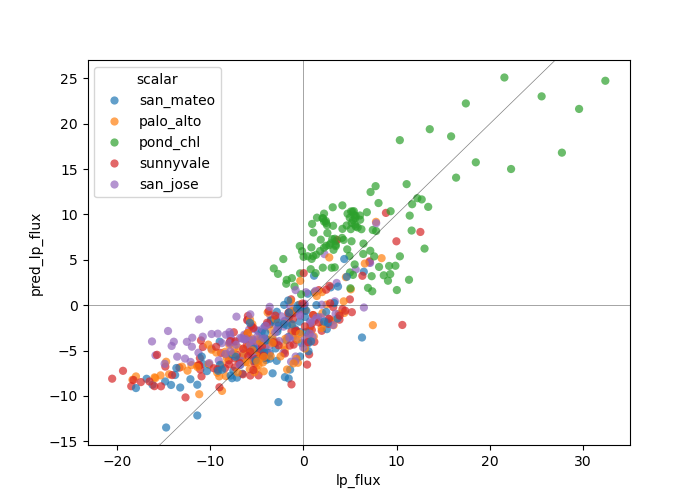

In [76]:
# points are every 30 minutes, and the results should be a tidal lowpass. Roughly
# we could plot every 48th point and get most of the variability 
fig=gfa.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:Qbar", annot=False, stride=48,
                 s=35, flip_sign=True) ;
ax=fig.axes[0]
rename={'sunnyvale':'Sunnyvale','san_jose':'San Jose', 'palo_alto':'Palo Alto','san_mateo':'San Mateo',
        'pond_chl':'Pond biomass'}
for l in ax.lines:
    txt = l.get_label()
    l.set_label( rename.get(txt,txt) )
ax.lines[-1].set_label('1:1 line')
ax.lines[-2].set_linestyle(':')
ax.lines[-3].set_linestyle(':')
ax.set_xlabel('Modeled flux (kg/s)')
ax.set_ylabel('Parameterized flux (kg/s)')
ax.legend(loc='lower right',title='Tracer',frameon=0)

fig.savefig("flux_scatter_20250113.png",dpi=200)

In [71]:
# Estimate a cross-sectional area

# nominal cross-sectional area 100 m2
# nominal excursion 6 km
# nominal 
# H vs. excursion:
# integrate u
# nominal tidal range: std(fas[1].depth()) = 0.73 m
# figure a 1.5m tidal swing gives an excursion of about 6km.


# super slow on S:
# just get one day:
# transect='alv2'
# Q=transect_flow(multi_run_dirs[1],transect)

# area=transect_flow(multi_run_dirs[1],transect,
#                    time_range=[np.datetime64("2016-07-10 00:00"),
#                                np.datetime64("2016-07-11 00:00")],
#                    quantity='area')

# fig,axs = plt.subplots(3,1,sharex=True)
# axs[0].plot(Q.time, Q,label='Q')
# axs[1].plot(area.time, area, label='area')
# u=Q/area
# #axs[2].plot(u.time, u, label='u')
# x=np.cumsum(u*dt_s)
# axs[2].plot(u.time, x, label='excursion')
# print(area.mean())

# dt_s = np.median(np.diff(area.time))/np.timedelta64(1,'s')
# nominal cross-sectional area 100 m2
# nominal excursion 6 km
# nominal 
# H vs. excursion:
# integrate u
# nominal tidal range: std(fas[1].depth()) = 0.73 m
# figure a 1.5m tidal swing gives an excursion of about 6km.

# np.std(gfa.fas[1].depth()) # 0.73

(5.70 / 100) * (6000 / 1.5) # 228 m2/s - pretty large
(2.71 / 100) * (6000 / 1.5) # 108 m2/s 

# Compare to Fischer scaling:
# 0.011 ubar^2 W^2 / d u*
# 

0.011 * 0.4**2 * 30**2 / (3 * 0.04)

13.200000000000003

<IPython.core.display.Javascript object>


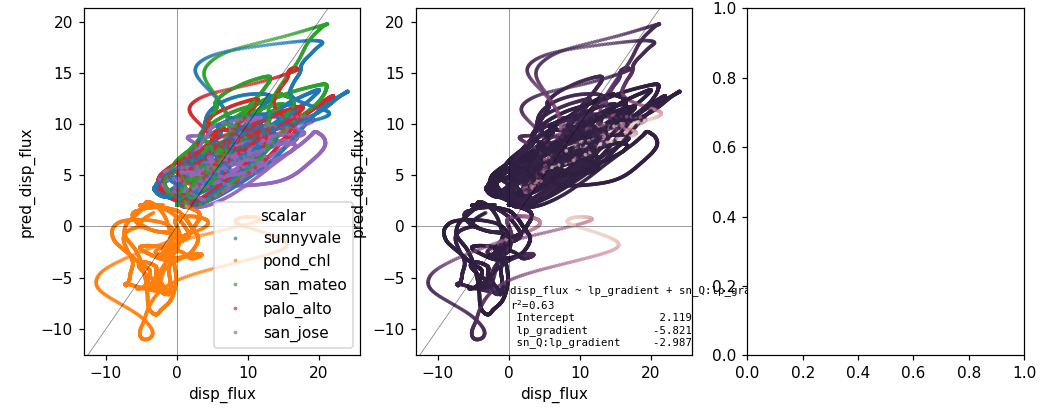

INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:0

In [20]:
gfa2=GroupFluxAnalysis(discharge_source='USGS')
gfa2.fig_fit_triptych() ;

<IPython.core.display.Javascript object>


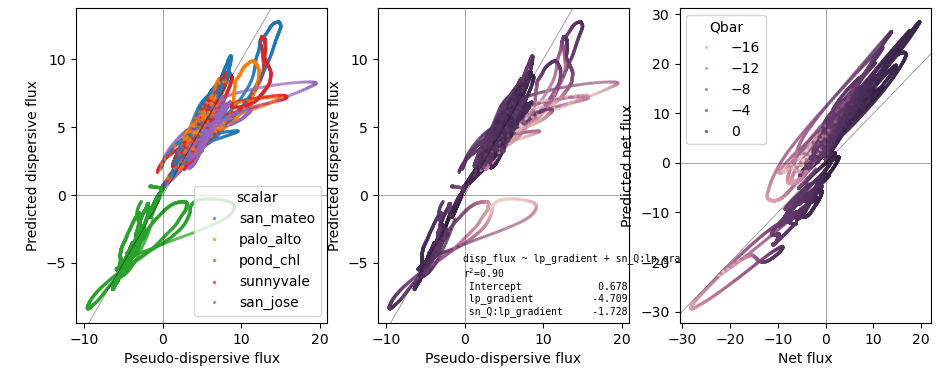

In [525]:
gfa3=GroupFluxAnalysis(gradient_source='central')
gfa3.fig_fit_triptych() ;

<IPython.core.display.Javascript object>


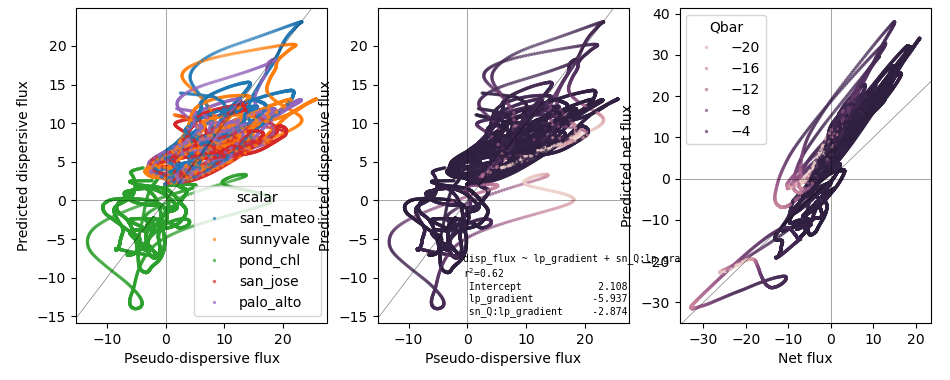

INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:0

In [524]:
gfa4=GroupFluxAnalysis(discharge_source='USGS',gradient_source='tidal')
gfa4.fig_fit_triptych() ;

<IPython.core.display.Javascript object>


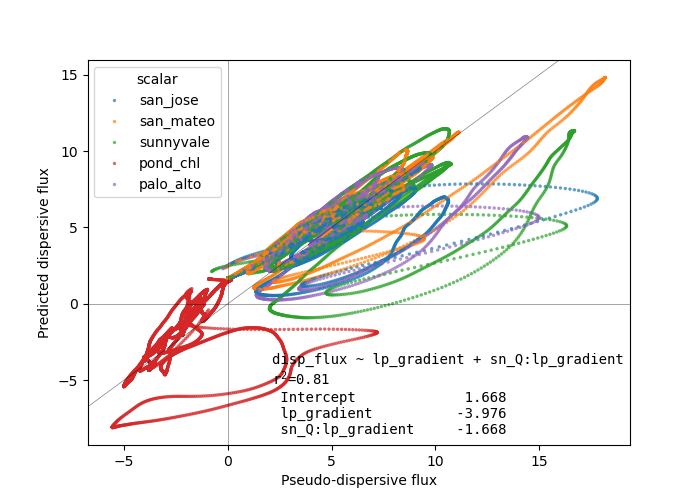

<IPython.core.display.Javascript object>


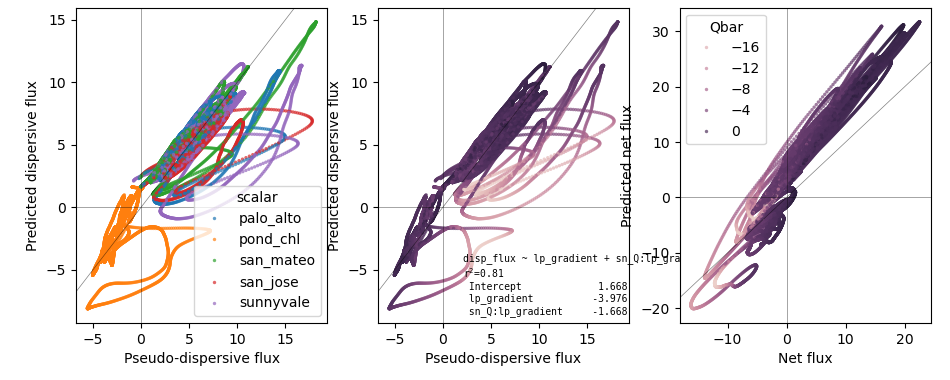

In [486]:
gfa_pond=GroupFluxAnalysis(up_station='s_notch',flux_station='alv1',mid_station='s_alv1',
                           down_station='s_alv2')

fig=gfa_pond.plot_fit();

gfa_pond.fig_fit_triptych() ;

<IPython.core.display.Javascript object>


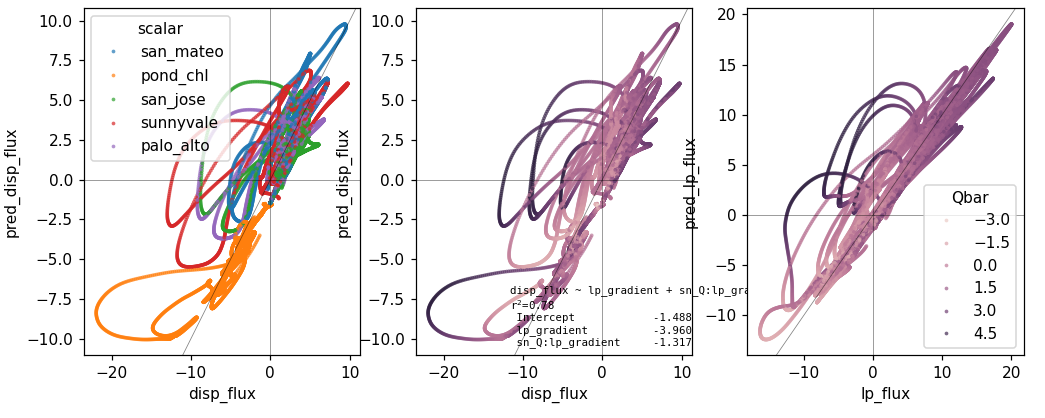

disp_flux ~ lp_gradient + sn_Q:lp_gradient
r^2=0.78
 Intercept            -1.488
 lp_gradient          -3.960
 sn_Q:lp_gradient     -1.317
disp_flux ~ lp_gradient + sn_Q:lp_gradient
r^2=0.78
 Intercept            -1.488
 lp_gradient          -3.960
 sn_Q:lp_gradient     -1.317
lp_flux ~ lp_gradient + sn_Q:lp_gradient + lp_C:Qbar
r^2=0.89
 Intercept            -1.400
 lp_gradient          -4.105
 sn_Q:lp_gradient     -1.418
 lp_C:Qbar             0.943


In [25]:
# r2 ~ 0.61, but I want flux at the notch, not alv1
#gfa_pond=GroupFluxAnalysis(up_station='s_notch',flux_station='alv1',mid_station='s_alv1',
#                           down_station='s_alv2', discharge_source='USGS')

# dispersive flux at the pond: r2 ~ 0.78, net flux r2 ~ 0.89.
gfa_pond=GroupFluxAnalysis(up_station='s_notch',flux_station='notch',mid_station='s_notch',
                           down_station='s_alv2')
gfa_pond.fig_fit_triptych() ;

18 mon areas
n_tran 17
17 transects


INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00


18 mon areas
n_tran 17
17 transects


INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00


lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:sn_H + lp_C:d_sn_H + QbarUSGS:lp_C
r^2=0.66
 Intercept            -4.112
 lp_gradient          -3.164
 sn_H:lp_gradient     -1.253
 lp_C:sn_H             0.753
 lp_C:d_sn_H           0.813
 QbarUSGS:lp_C         0.125


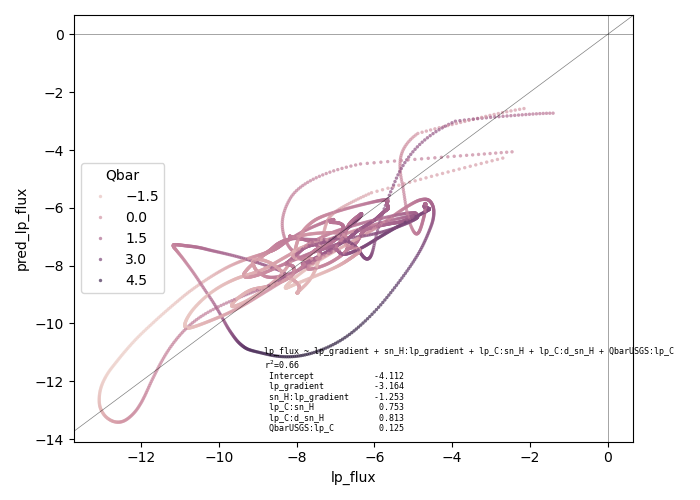

In [36]:
gfa1=GroupFluxAnalysis(up_station='s_notch',flux_station='notch',mid_station='s_notch',
                       down_station='s_alv2', gradient_source='tidal')
# This one is amazing -- but the form of the USGS term is hard to justify and we don't 
# have the observations to use it in practice.
#fig1=gfa1.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:Qbar + lp_C:QbarUSGS",hue='sn_H') ;

# mostly the same as original. r2=0.90
#fig1=gfa1.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:Qbar + QbarUSGS:lp_gradient",hue='Qbar');

# Trying to sneak in sn_H as a proxy for DWAQ's Qbar -- it doesn't work, and physically I want
# the time-derivative of sn_H, not sn_H. r2=0.80
#fig1=gfa1.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:sn_H + QbarUSGS:lp_C",hue='Qbar');

fig1=gfa1.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:sn_H + lp_C:d_sn_H + QbarUSGS:lp_C",
                   hue='Qbar',annot=dict(fontsize=6));

# So try time derivative of sn_H. No joy. r2=0.75.
# Even better (?), time derivative of lp_H. Nope, worse. r2=0.69
# Even though d_lp_H seems like the right term, lp_H does a bit better and plots better on top
# of Qbar.
# There is some lag -- can offer both terms and the fitting find the lag. No help.
#fig1=gfa1.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:lp_H + QbarUSGS:lp_C",
#                   hue='Qbar');
fig1.tight_layout()

INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:0

lp_flux ~ lp_gradient + sn_H:lp_gradient 
          + lp_C:sn_H + lp_C:d_sn_H
r^2=0.90
 Intercept             4.481
 lp_gradient          -10.510
 sn_H:lp_gradient     -2.181
 lp_C:sn_H             0.783
 lp_C:d_sn_H           0.852


INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:0

lp_flux ~ lp_gradient + sn_H:lp_gradient 
          + lp_C:sn_H + lp_C:d_sn_H
r^2=0.91
 Intercept             4.185
 lp_gradient          -10.827
 sn_H:lp_gradient     -2.186
 lp_C:sn_H             0.774
 lp_C:d_sn_H           0.848


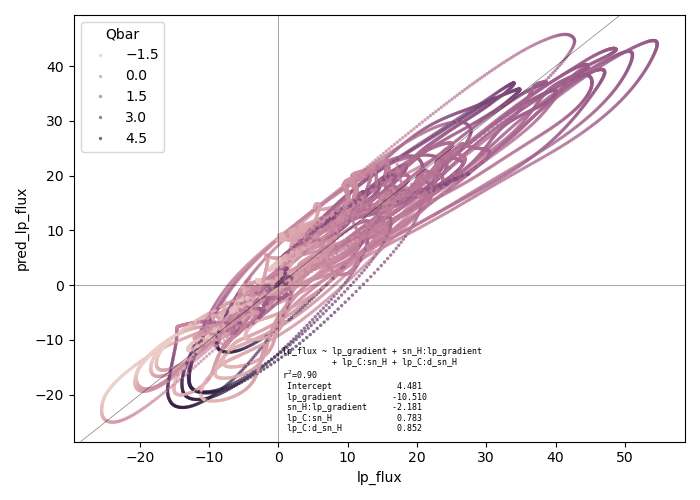

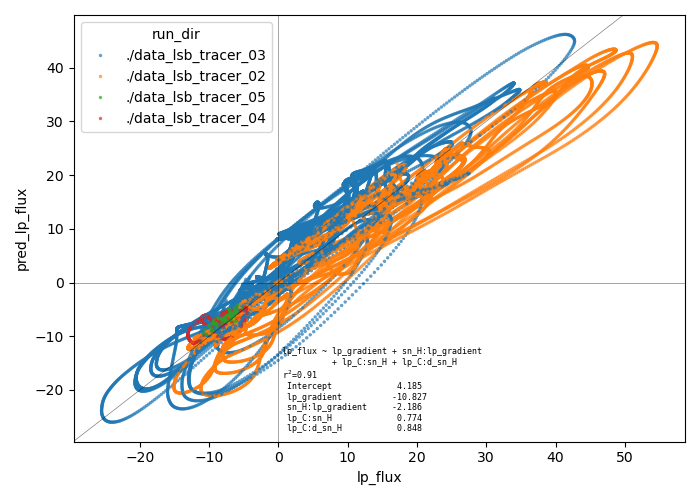

In [63]:
# Closer look at notch fluxes, with fast decay tracer vs regular tracers

kw=dict(
    up_station='s_notch',flux_station='notch',mid_station='s_notch',  
    down_station='s_alv2', gradient_source='tidal', trim_ends=np.timedelta64(36,'h')
)

formula="lp_flux ~ lp_gradient + sn_H:lp_gradient \n          + lp_C:sn_H + lp_C:d_sn_H"

if 1:
    gfa_reg=GroupFluxAnalysis(run_dirs=multi_run_dirs,**kw)
    fig1=gfa_reg.plot_fit(formula=formula, hue='Qbar', annot=dict(fontsize=6));
    fig1.tight_layout()
if 0:
    gfa_fast=GroupFluxAnalysis(run_dirs=multi_run_dirs_decay,**kw)
    fig2=gfa_fast.plot_fit(formula=formula, hue='Qbar', annot=dict(fontsize=6));
    fig2.tight_layout()
    
gfa_combined = GroupFluxAnalysis(run_dirs=multi_run_dirs + multi_run_dirs_decay,**kw)
fig3=gfa_combined.plot_fit(formula=formula, hue='run_dir', annot=dict(fontsize=6));
fig3.tight_layout()


In [106]:
# Can we get around one of the weakness of that best performing model by finding a surrogate
# for notch mean discharge? 
gfa1=GroupFluxAnalysis(up_station='s_notch',flux_station='notch',mid_station='s_notch',
                       down_station='s_alv2', scalars=['san_jose'])
df=gfa1.df()
df = df.sort_values('time')

# including QbarUSGS, lp_H, d_lp_H made almost no improvement.
# dropping either of these drops the correlation substantially.
result = smf.ols("Qbar ~ sn_H + d_sn_H", data=df).fit()
Qbar_pred = result.predict()
result.summary()

INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Qbar   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     5957.
Date:                Wed, 01 May 2024   Prob (F-statistic):               0.00
Time:                        21:33:50   Log-Likelihood:                -7035.3
No. Observations:                6146   AIC:                         1.408e+04
Df Residuals:                    6143   BIC:                         1.410e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7002      0.010     72.194      0.000       0.681       0.719
sn_H           0.8054      0.010     83.043      0.000       0.786       0.824
d_sn_H         0.9545      0.014     69.940      0.000       0.928       0.981
==============================================================================
Omnibus:                     1639.487   Durbin-Watson:                   0.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17195.502
Skew:                           0.971   Prob(JB):                         0.00
Kurtosis:                      10.961   Cond. No.                         1.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<IPython.core.display.Javascript object>


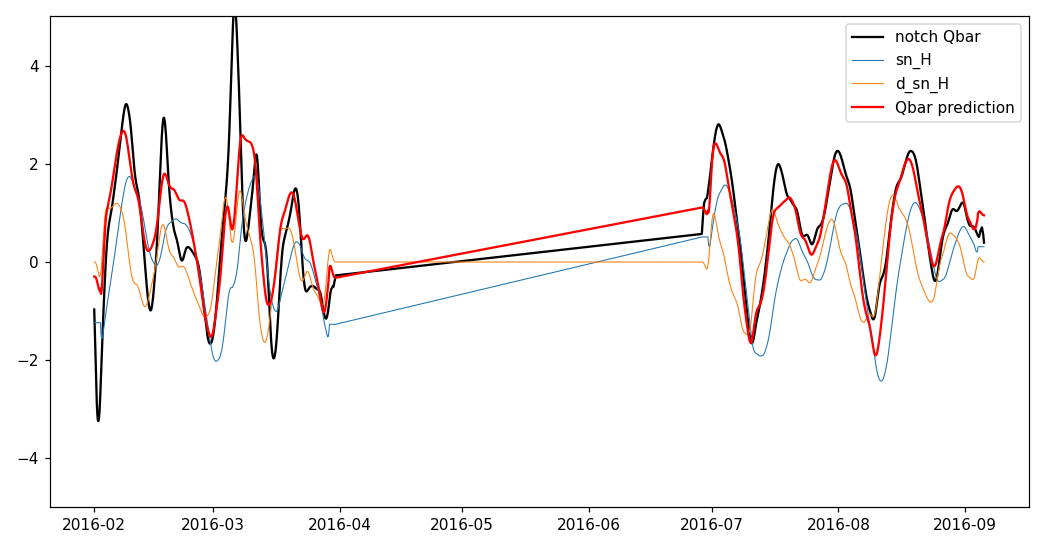

In [109]:
fig,ax=plt.subplots(figsize=(9.5,5))

ax.plot(df.time, df.Qbar, label='notch Qbar',color='k')
# sn_H appears related, slightly lagged relative to Qbar.
ax.plot(df.time, df.sn_H, label='sn_H',lw=0.7)
ax.plot(df.time, df.d_sn_H, label='d_sn_H',lw=0.7)
ax.plot(df.time, Qbar_pred, label='Qbar prediction',color='r')

ax.legend()
ax.axis(ymin=-5,ymax=5)
fig.tight_layout()

<IPython.core.display.Javascript object>


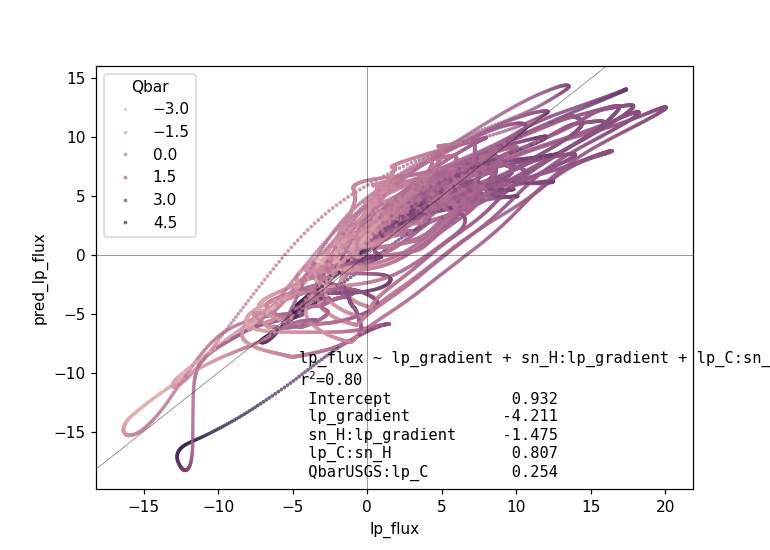

INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:00:00
INFO:usgs_nwis:Cached   2016-09-01 00:00:00 -- 2016-10-01 00:00:00
INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00
INFO:usgs_nwis:Cached   2016-06-01 00:00:00 -- 2016-07-01 00:00:00
INFO:usgs_nwis:Cached   2016-07-01 00:00:00 -- 2016-08-01 00:00:00
INFO:usgs_nwis:Cached   2016-08-01 00:00:00 -- 2016-09-01 00:0

lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:sn_H + QbarUSGS:lp_C
r^2=0.80
 Intercept             0.932
 lp_gradient          -4.211
 sn_H:lp_gradient     -1.475
 lp_C:sn_H             0.807
 QbarUSGS:lp_C         0.254


In [45]:
#gfa2=GroupFluxAnalysis(up_station='s_notch',flux_station='notch',mid_station='s_notch',
#                       down_station='s_alv2', discharge_source='USGS')
#fig2=gfa2.plot_fit(formula="lp_flux ~ lp_gradient + sn_H:lp_gradient + lp_C:Qbar",hue='sn_H') ;

In [35]:
gfa1.df().columns

Index(['time', 'scalar', 'lp_gradient', 'lp_C', 'lp_flux', 'disp_flux', 'sn_Q',
       'sn_H', 'Q', 'Qbar', 'QbarUSGS', 'QbarDWAQ'],
      dtype='object')

In [225]:
#formula="disp_flux ~ lp_gradient" # 0.85
#formula="disp_flux ~ lp_gradient + sn_Q" # 0.90
formula="disp_flux ~ lp_gradient * sn_Q"  # 0.976!

formula="disp_flux ~ lp_gradient + lp_gradient : sn_Q" # 0.974 ! 

print(formula)
df=gfa.df()
result = smf.ols(formula,data=df).fit()
df_ordered=df.sort_values('lp_gradient')
y_ordered=result.predict(exog=df_ordered)
ax=fig.axes[0]
ax.plot(df_ordered['lp_gradient'],y_ordered,'k-',label='Fit')

result.summary()

disp_flux ~ lp_gradient + lp_gradient : sn_Q


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              disp_flux   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                 3.148e+05
Date:                Fri, 16 Feb 2024   Prob (F-statistic):               0.00
Time:                        17:00:26   Log-Likelihood:                -15160.
No. Observations:               16565   AIC:                         3.033e+04
Df Residuals:                   16562   BIC:                         3.035e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.5374      0.006     95.738      0.000       0.526       0.548
lp_gradient         -4.6945      0.006   -793.189      0.000      -4.706      -4.683
lp_gradient:sn_Q    -1.3591      0.005   -283.365      0.000      -1.368      -1.350
==============================================================================
Omnibus:                     3122.782   Durbin-Watson:                   0.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5342.408
Skew:                           1.246   Prob(JB):                         0.00
Kurtosis:                       4.238   Cond. No.                         2.04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Observed Discharge
--

How does overall skill change when using an observable quantity for the
mean flow?

<IPython.core.display.Javascript object>


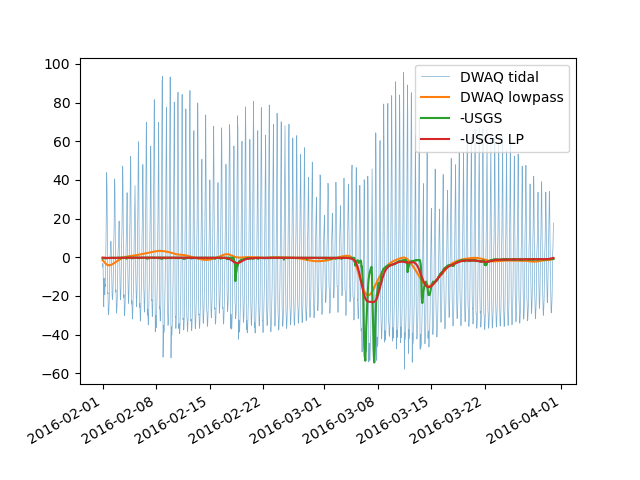

INFO:usgs_nwis:Cached   2016-02-01 00:00:00 -- 2016-03-01 00:00:00
INFO:usgs_nwis:Cached   2016-03-01 00:00:00 -- 2016-04-01 00:00:00


<IPython.core.display.Javascript object>


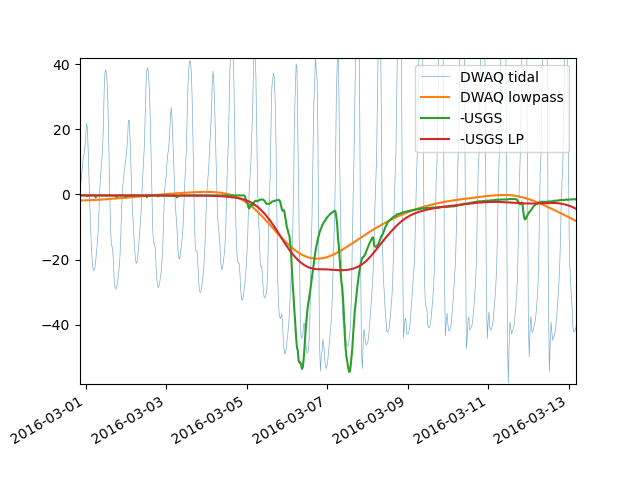

(16860.86, 16873.182, -58.1482, 41.98)

In [421]:
fa=FluxAnalysis(scalar='san_jose')
fig,ax=fa.fig_discharge()

fig,ax=fa.fig_discharge()
ax.axis( (16860.86, 16873.182, -58.1482, 41.98) )

In [94]:
# Locations of sources, aside from the pond

bdefs = hydros['summer'].boundary_defs()

INFO:HydroFiles:Inferring 2D elements, 0 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 50000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 100000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 150000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 200000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 250000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 300000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 350000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 400000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 450000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 500000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 550000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 600000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 650000 / 1107830 3-D segments
INFO:HydroFiles:Inferring 2D elements, 7